# 🎯 Đánh giá Mô hình trên Tập Dữ liệu Tự Thu thập (VTV24)

> Tính điểm **BLEU-1 → BLEU-4** cho cả hai mô hình **Baseline** và **Soft-Attention**  
> trên tập dữ liệu custom thu thập từ VTV24, sử dụng **Beam Search (K=5)**.

| Thông tin | Chi tiết |
|---|---|
| Nguồn ảnh | `../self_collect/img/` |
| Ground Truth | `../self_collect/caption.txt` |
| Số lượng | 500 ảnh |
| Beam Size | 5 |

---

## 1. Import & Thiết lập

In [1]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import json, yaml, os, glob, warnings
import numpy as np
from PIL import Image
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.models.Resnet101 import Encoder
from src.models.Decoder import DecoderWithAttention
from src.models.DecodeNoAttention import DecoderNoAttention

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Thiết bị: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')


✅ Thiết bị: cuda
   GPU: NVIDIA GeForce RTX 3060


## 2. Cấu hình

In [2]:
with open('../configs/default.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DATA_FOLDER   = os.path.join('../', cfg['dataset']['data_folder'])
DATA_NAME     = cfg['dataset']['data_name']
EMB_DIM       = cfg['model']['emb_dim']
ATTENTION_DIM = cfg['model']['attention_dim']
DECODER_DIM   = cfg['model']['decoder_dim']
DROPOUT       = cfg['model']['dropout']
BEAM_SIZE     = 5

CKPT_ATT  = f'../weights/attention/BEST_checkpoint_{DATA_NAME}.pth.tar'
CKPT_BASE = f'../weights/no_attention/BEST_checkpoint_{DATA_NAME}.pth.tar'

SELF_COLLECT_DIR = '../self_collect'
CAPTION_FILE     = '../self_collect/caption.txt'
SUPPORTED_EXT    = ('*.jpg', '*.jpeg', '*.png')

# Đọc word map
word_map_file = os.path.join(DATA_FOLDER, f'WORDMAP_{DATA_NAME}.json')
with open(word_map_file, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}
vocab_size   = len(word_map)

print(f'[*] Dataset   : {DATA_NAME}')
print(f'[*] Vocab size: {vocab_size:,} từ')
print(f'[*] Beam size : {BEAM_SIZE}')


[*] Dataset   : coco_5_cap_per_img_5_min_word_freq
[*] Vocab size: 9,490 từ
[*] Beam size : 5


## 3. Nạp Mô hình

In [3]:
# ── Encoder (dùng chung) ──────────────────────────────────────────────────────
encoder = Encoder().to(device)

# ── Attention Decoder ─────────────────────────────────────────────────────────
decoder_att = DecoderWithAttention(
    attention_dim=ATTENTION_DIM, embed_dim=EMB_DIM,
    decoder_dim=DECODER_DIM, vocab_size=vocab_size, dropout=DROPOUT
).to(device)

ckpt_att = torch.load(CKPT_ATT, map_location=device, weights_only=False)
encoder.load_state_dict(ckpt_att['encoder'])
decoder_att.load_state_dict(ckpt_att['decoder'])
print(f'[*] Attention  checkpoint: {CKPT_ATT}')
print(f'    BLEU-4 (COCO val)    : {ckpt_att["bleu-4"]:.4f}')

# ── Baseline Decoder ──────────────────────────────────────────────────────────
decoder_base = DecoderNoAttention(
    attention_dim=ATTENTION_DIM, embed_dim=EMB_DIM,
    decoder_dim=DECODER_DIM, vocab_size=vocab_size, dropout=DROPOUT
).to(device)

ckpt_base = torch.load(CKPT_BASE, map_location=device, weights_only=False)
decoder_base.load_state_dict(ckpt_base['decoder'])
print(f'[*] Baseline   checkpoint: {CKPT_BASE}')
print(f'    BLEU-4 (COCO val)    : {ckpt_base["bleu-4"]:.4f}')

encoder.eval(); decoder_att.eval(); decoder_base.eval()
print('\n✅ Nạp mô hình thành công')


[*] Attention  checkpoint: ../weights/attention/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar
    BLEU-4 (COCO val)    : 0.1905
[*] Baseline   checkpoint: ../weights/no_attention/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar
    BLEU-4 (COCO val)    : 0.2045

✅ Nạp mô hình thành công


## 4. Hàm Beam Search & Tiền xử lý

In [4]:
_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess(img_path):
    img = Image.open(img_path).convert('RGB')
    return _transform(img).unsqueeze(0).to(device)

def ids_to_words(seq):
    ignore = {word_map['<start>'], word_map['<end>'], word_map['<pad>']}
    return [rev_word_map[w] for w in seq if w not in ignore]

def beam_search_attention(encoder_out, dec, k=5):
    enc_dim = encoder_out.size(-1)
    enc = encoder_out.view(1, -1, enc_dim).expand(k, -1, enc_dim)
    prev_words   = torch.LongTensor([[word_map['<start>']]] * k).to(device)
    seqs         = prev_words
    top_k_scores = torch.zeros(k, 1).to(device)
    h, c = dec.init_hidden_state(enc)
    complete_seqs, complete_scores = [], []
    step = 1
    while True:
        emb = dec.embedding(prev_words).squeeze(1)
        awe, _ = dec.attention(enc, h)
        gate = dec.sigmoid(dec.f_beta(h))
        h, c = dec.decode_step(torch.cat([emb, gate * awe], dim=1), (h, c))
        scores = top_k_scores.expand_as(F.log_softmax(dec.fc(h), dim=1)) \
                 + F.log_softmax(dec.fc(h), dim=1)
        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)
        prev_inds = top_k_words // vocab_size
        next_inds = top_k_words  % vocab_size
        seqs = torch.cat([seqs[prev_inds], next_inds.unsqueeze(1)], dim=1)
        incomplete = [i for i, w in enumerate(next_inds) if w != word_map['<end>']]
        complete   = list(set(range(len(next_inds))) - set(incomplete))
        if complete:
            complete_seqs.extend(seqs[complete].tolist())
            complete_scores.extend(top_k_scores[complete])
        k -= len(complete)
        if k == 0 or step > 50: break
        seqs = seqs[incomplete]; h = h[prev_inds[incomplete]]; c = c[prev_inds[incomplete]]
        enc = enc[prev_inds[incomplete]]
        top_k_scores = top_k_scores[incomplete].unsqueeze(1)
        prev_words   = next_inds[incomplete].unsqueeze(1)
        step += 1
    seq = complete_seqs[complete_scores.index(max(complete_scores))] \
          if complete_scores else seqs[0].tolist()
    return ids_to_words(seq)

def beam_search_baseline(encoder_out, dec, k=5):
    enc_dim = encoder_out.size(-1)
    enc = encoder_out.view(1, -1, enc_dim).expand(k, -1, enc_dim)
    prev_words   = torch.full((k, 1), word_map['<start>'], dtype=torch.long, device=device)
    seqs         = prev_words
    top_k_scores = torch.zeros(k, 1, device=device)
    h, c = dec.init_hidden_state(enc)
    complete_seqs, complete_scores = [], []
    step = 1
    while True:
        emb  = dec.embedding(prev_words).squeeze(1)
        gate = dec.sigmoid(dec.f_beta(h))
        h, c = dec.decode_step(torch.cat([emb, gate], dim=1), (h, c))
        scores = F.log_softmax(dec.fc(h), dim=1)
        scores = top_k_scores.expand_as(scores) + scores
        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)
        prev_inds = top_k_words // vocab_size
        next_inds = top_k_words  % vocab_size
        seqs = torch.cat([seqs[prev_inds], next_inds.unsqueeze(1)], dim=1)
        incomplete = [i for i, w in enumerate(next_inds) if w != word_map['<end>']]
        complete   = list(set(range(len(next_inds))) - set(incomplete))
        if complete:
            complete_seqs.extend(seqs[complete].tolist())
            complete_scores.extend(top_k_scores[complete].cpu().tolist())
        k -= len(complete)
        if k == 0 or step > 50: break
        seqs = seqs[incomplete]; h = h[prev_inds[incomplete]]; c = c[prev_inds[incomplete]]
        top_k_scores = top_k_scores[incomplete].unsqueeze(1)
        prev_words   = next_inds[incomplete].unsqueeze(1)
        step += 1
    seq = complete_seqs[complete_scores.index(max(complete_scores))] \
          if complete_scores else seqs[0].tolist()
    return ids_to_words(seq)

print('✅ Định nghĩa hàm thành công')


✅ Định nghĩa hàm thành công


## 5. Nạp Dữ liệu VTV24

In [5]:
# ── Tìm ảnh ──────────────────────────────────────────────────────────────────
img_paths = []
for ext in SUPPORTED_EXT:
    img_paths += glob.glob(os.path.join(SELF_COLLECT_DIR, ext))
    img_paths += glob.glob(os.path.join(SELF_COLLECT_DIR, '**', ext), recursive=True)
img_paths = sorted(set(img_paths))
print(f'[*] Số ảnh tìm thấy: {len(img_paths)}')

# ── Đọc caption.txt (ground truth) ───────────────────────────────────────────
# Format: tên_file.jpg\t\tcaption
ground_truth = {}
with open(CAPTION_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        parts = [p.strip() for p in line.split('\t') if p.strip()]
        if len(parts) >= 2:
            ground_truth[parts[0]] = parts[-1]

print(f'[*] Ground truth: {len(ground_truth)} captions')
print(f'[*] Ảnh có GT   : {sum(1 for p in img_paths if os.path.basename(p) in ground_truth)}')


[*] Số ảnh tìm thấy: 503
[*] Ground truth: 500 captions
[*] Ảnh có GT   : 500


## 6. Chạy Beam Search & Tính BLEU

In [6]:
references_att  = []
hypotheses_att  = []
references_base = []
hypotheses_base = []

with torch.no_grad():
    for img_path in tqdm(img_paths, desc='Đang đánh giá'):
        fname = os.path.basename(img_path)
        gt    = ground_truth.get(fname, None)
        if gt is None:
            continue  # Bỏ qua ảnh không có ground truth

        tensor  = preprocess(img_path)
        enc_out = encoder(tensor)

        # Attention
        pred_att  = beam_search_attention(enc_out.clone(), decoder_att,  k=BEAM_SIZE)
        # Baseline
        pred_base = beam_search_baseline(enc_out.clone(), decoder_base, k=BEAM_SIZE)

        ref_tokens = gt.lower().split()
        references_att.append([ref_tokens])
        hypotheses_att.append(pred_att)
        references_base.append([ref_tokens])
        hypotheses_base.append(pred_base)

print(f'\n[*] Đã xử lý {len(hypotheses_att)} ảnh có ground truth')
print('[*] Đang tính BLEU scores...')

# ── Tính BLEU-1 → BLEU-4 ─────────────────────────────────────────────────────
def calc_bleu(refs, hyps):
    b1 = corpus_bleu(refs, hyps, weights=(1, 0, 0, 0))
    b2 = corpus_bleu(refs, hyps, weights=(0.5, 0.5, 0, 0))
    b3 = corpus_bleu(refs, hyps, weights=(0.33, 0.33, 0.33, 0))
    b4 = corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25))
    return b1, b2, b3, b4

att_b1,  att_b2,  att_b3,  att_b4  = calc_bleu(references_att,  hypotheses_att)
base_b1, base_b2, base_b3, base_b4 = calc_bleu(references_base, hypotheses_base)

print('✅ Tính toán xong')


Đang đánh giá: 100%|████████████████████████████████████████████████| 503/503 [00:28<00:00, 17.71it/s]



[*] Đã xử lý 500 ảnh có ground truth
[*] Đang tính BLEU scores...
✅ Tính toán xong


## 7. Kết quả

In [7]:
SEP  = '═' * 50
SEP2 = '─' * 50

def print_report(title, b1, b2, b3, b4, n_imgs):
    print(f'\n {SEP}')
    print(f'  {title}')
    print(f' {SEP}')
    print(f'  ► Thiết bị tính toán  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
    print(f'  ► Kích thước Beam Search : {BEAM_SIZE}')
    print(f'  ► Tổng số ảnh thực nghiệm: {n_imgs} ảnh')
    print(f' {SEP2}')
    print(f'  ► BLEU-1 Score    :  {b1*100:.2f}%')
    print(f'  ► BLEU-2 Score    :  {b2*100:.2f}%')
    print(f'  ► BLEU-3 Score    :  {b3*100:.2f}%')
    print(f'  ► BLEU-4 Score    :  {b4*100:.2f}%')
    print(f' {SEP}\n')

n = len(hypotheses_att)
print_report('🏁 BÁO CÁO KẾT QUẢ MÔ HÌNH BASELINE (NO-ATTENTION)',
             base_b1, base_b2, base_b3, base_b4, n)

print_report('🎯 BÁO CÁO KẾT QUẢ MÔ HÌNH ĐỀ XUẤT (SOFT-ATTENTION)',
             att_b1,  att_b2,  att_b3,  att_b4,  n)



 ══════════════════════════════════════════════════
  🏁 BÁO CÁO KẾT QUẢ MÔ HÌNH BASELINE (NO-ATTENTION)
 ══════════════════════════════════════════════════
  ► Thiết bị tính toán  : NVIDIA GeForce RTX 3060
  ► Kích thước Beam Search : 5
  ► Tổng số ảnh thực nghiệm: 500 ảnh
 ──────────────────────────────────────────────────
  ► BLEU-1 Score    :  23.03%
  ► BLEU-2 Score    :  11.73%
  ► BLEU-3 Score    :  7.41%
  ► BLEU-4 Score    :  4.84%
 ══════════════════════════════════════════════════


 ══════════════════════════════════════════════════
  🎯 BÁO CÁO KẾT QUẢ MÔ HÌNH ĐỀ XUẤT (SOFT-ATTENTION)
 ══════════════════════════════════════════════════
  ► Thiết bị tính toán  : NVIDIA GeForce RTX 3060
  ► Kích thước Beam Search : 5
  ► Tổng số ảnh thực nghiệm: 500 ảnh
 ──────────────────────────────────────────────────
  ► BLEU-1 Score    :  24.02%
  ► BLEU-2 Score    :  12.13%
  ► BLEU-3 Score    :  7.19%
  ► BLEU-4 Score    :  4.50%
 ══════════════════════════════════════════════════



## 8. Bảng So sánh Tổng hợp

In [8]:
import pandas as pd
from IPython.display import display, Markdown

df = pd.DataFrame({
    'Chỉ số': ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'],
    'Baseline (No-Attention) %': [
        f'{base_b1*100:.2f}', f'{base_b2*100:.2f}',
        f'{base_b3*100:.2f}', f'{base_b4*100:.2f}'
    ],
    'Proposed (Soft-Attention) %': [
        f'{att_b1*100:.2f}', f'{att_b2*100:.2f}',
        f'{att_b3*100:.2f}', f'{att_b4*100:.2f}'
    ],
    'Cải thiện %': [
        f'+{(att_b1-base_b1)*100:.2f}', f'+{(att_b2-base_b2)*100:.2f}',
        f'+{(att_b3-base_b3)*100:.2f}', f'+{(att_b4-base_b4)*100:.2f}'
    ]
})

display(
    df.style
      .set_table_styles([
          {'selector': 'th', 'props': [('background-color','#2C3E50'),('color','white'),
                                        ('font-size','13px'),('text-align','center'),('padding','10px 16px')]},
          {'selector': 'td', 'props': [('font-size','12px'),('padding','9px 16px'),('text-align','center')]},
          {'selector': 'tr:nth-child(even) td', 'props': [('background-color','#F0F4F8')]},
          {'selector': 'td:last-child', 'props': [('color','#27AE60'),('font-weight','bold')]},
      ])
      .hide(axis='index')
)

display(Markdown(f"""
---
**Tóm tắt:** Trên tập dữ liệu tự thu thập VTV24 ({n} ảnh),  
mô hình Soft-Attention cải thiện **BLEU-4 +{(att_b4-base_b4)*100:.2f}%** so với Baseline.
"""))


Chỉ số,Baseline (No-Attention) %,Proposed (Soft-Attention) %,Cải thiện %
BLEU-1,23.03,24.02,+0.99
BLEU-2,11.73,12.13,+0.40
BLEU-3,7.41,7.19,+-0.22
BLEU-4,4.84,4.50,+-0.34



---
**Tóm tắt:** Trên tập dữ liệu tự thu thập VTV24 (500 ảnh),  
mô hình Soft-Attention cải thiện **BLEU-4 +-0.34%** so với Baseline.


## 9. Biểu đồ So sánh BLEU (VTV24 vs MS COCO)

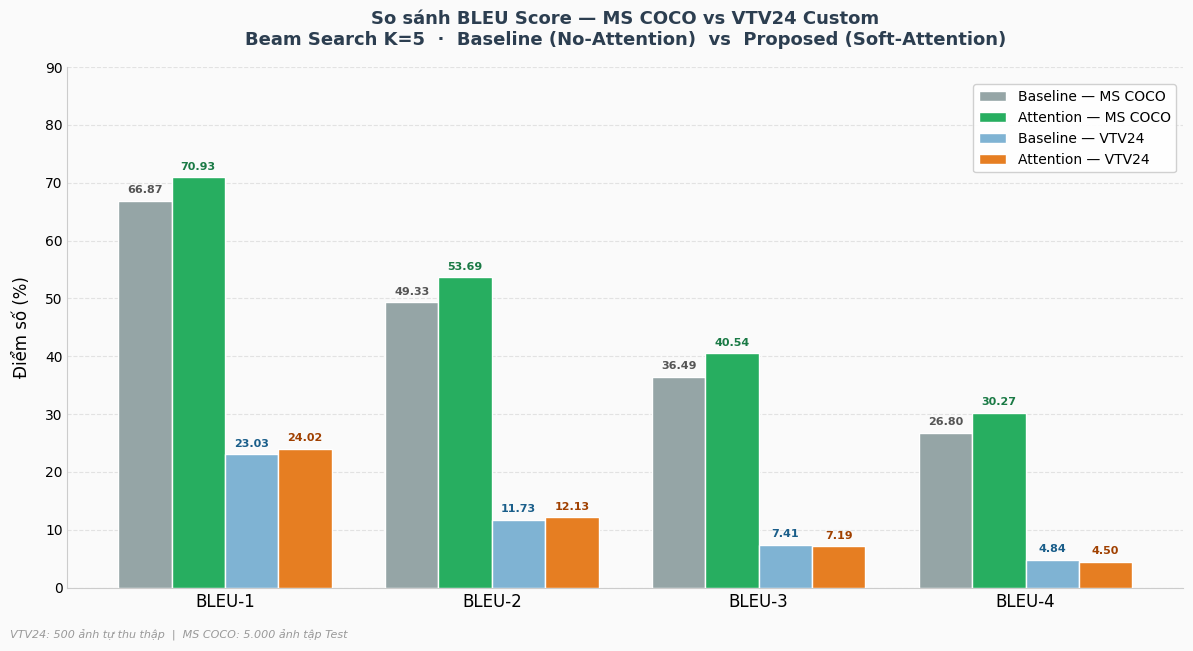

✅ Đã lưu → ../results/vtv24_bleu_comparison.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']

# Điểm VTV24 (vừa tính)
vtv_base = [base_b1*100, base_b2*100, base_b3*100, base_b4*100]
vtv_att  = [att_b1*100,  att_b2*100,  att_b3*100,  att_b4*100]

# Điểm MS COCO (thực nghiệm)
coco_base = [66.87, 49.33, 36.49, 26.80]
coco_att  = [70.93, 53.69, 40.54, 30.27]

x     = np.arange(len(metrics))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

r1 = ax.bar(x - 1.5*width, coco_base, width, label='Baseline — MS COCO',   color='#95A5A6', edgecolor='white', zorder=3)
r2 = ax.bar(x - 0.5*width, coco_att,  width, label='Attention — MS COCO',  color='#27AE60', edgecolor='white', zorder=3)
r3 = ax.bar(x + 0.5*width, vtv_base,  width, label='Baseline — VTV24',     color='#7FB3D3', edgecolor='white', zorder=3)
r4 = ax.bar(x + 1.5*width, vtv_att,   width, label='Attention — VTV24',    color='#E67E22', edgecolor='white', zorder=3)

def autolabel(rects, color):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

autolabel(r1, '#555555'); autolabel(r2, '#1A7A45')
autolabel(r3, '#1A5E8A'); autolabel(r4, '#A04000')

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
ax.set_ylabel('Điểm số (%)', fontsize=12, labelpad=10)
ax.set_title(
    'So sánh BLEU Score — MS COCO vs VTV24 Custom\n'
    'Beam Search K=5  ·  Baseline (No-Attention)  vs  Proposed (Soft-Attention)',
    fontsize=13, fontweight='bold', pad=16, color='#2C3E50'
)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 90)
ax.tick_params(axis='both', length=0)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['left','bottom']: ax.spines[sp].set_color('#CCCCCC')

ax.legend(fontsize=10, framealpha=0.9, edgecolor='#CCCCCC',
          loc='upper right', bbox_to_anchor=(1.0, 0.98))
fig.text(0.01, 0.01,
         f'VTV24: {n} ảnh tự thu thập  |  MS COCO: 5.000 ảnh tập Test',
         fontsize=8, color='#999999', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 1])
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/vtv24_bleu_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('✅ Đã lưu → ../results/vtv24_bleu_comparison.png')
